به نام خدا

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)


100%|██████████| 9.91M/9.91M [00:10<00:00, 905kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.88MB/s]


In [3]:

batch_size = 64
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

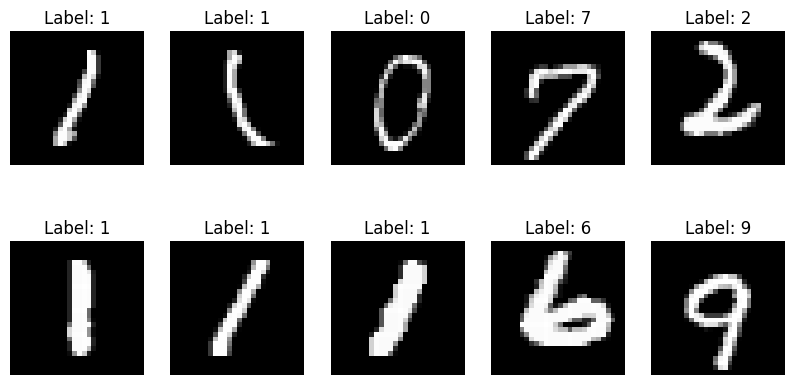

In [4]:
images, labels = next(iter(train_loader))
fig = plt.figure(figsize=(10, 5))
for i in range(10):
    ax = fig.add_subplot(2, 5, i+1)
    ax.imshow(images[i][0], cmap='gray')
    ax.set_title(f"Label: {labels[i]}")
    ax.axis('off')
plt.show()

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MNISTMLP(nn.Module):
    def __init__(self,n_neurons):
        super(MNISTMLP, self).__init__()

        self.fc1 = nn.Linear(784,
                             n_neurons)
        self.fc2 = nn.Linear(n_neurons,
                             n_neurons)
        self.fc3 = nn.Linear(n_neurons,
                             n_neurons)
        self.fc4 = nn.Linear(n_neurons,
                             10)

        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = x.view(-1, 784)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))


        x = self.softmax(self.fc4(x))
        return x

In [6]:
model = MNISTMLP(512)
print(model)

MNISTMLP(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=512, bias=True)
  (fc4): Linear(in_features=512, out_features=10, bias=True)
  (relu): ReLU()
  (softmax): Softmax(dim=1)
)


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"Using device: {device}")


Using device: cuda


In [8]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:

num_epochs = 25
for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {train_acc:.2f}%")



KeyboardInterrupt: 

Test Accuracy: 89.85%


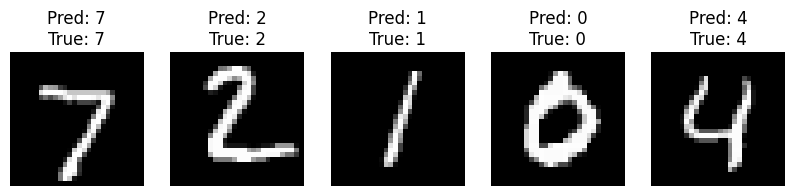

In [ ]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

model.eval()
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(device)
with torch.no_grad():
    outputs = model(test_images[:5])
_, predicted = torch.max(outputs, 1)

test_images = test_images.cpu()
predicted = predicted.cpu()

fig = plt.figure(figsize=(10, 5))
for i in range(5):
    ax = fig.add_subplot(1, 5, i+1)
    ax.imshow(test_images[i][0], cmap='gray')
    ax.set_title(f"Pred: {predicted[i]}\nTrue: {test_labels[i]}")
    ax.axis('off')
plt.show()

In [13]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 23.9 MB/s eta 0:00:00


In [14]:
import optuna


In [17]:
def objective(trial):
    batch_size = trial.suggest_categorical("batch_size", [16,32,64, 128])
    hidden = trial.suggest_categorical("h1_size", [32,64,128])
    lr = trial.suggest_categorical("lr", [0.1,0.01, 0.001])

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = MNISTMLP(hidden).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0
    for epoch in range(25):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = correct / total
        trial.report(val_acc, epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        best_val_acc = max(best_val_acc, val_acc)

    return best_val_acc


In [18]:
storage = optuna.storages.InMemoryStorage()

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(),
    pruner=optuna.pruners.MedianPruner(),
    storage=storage
)
study.optimize(objective, n_trials=30)

[I 2025-04-20 05:25:50,321] A new study created in memory with name: no-name-d05fd80b-8dd2-4634-97ca-c0ac37231c0e
[I 2025-04-20 05:33:45,361] Trial 0 finished with value: 0.9509 and parameters: {'batch_size': 32, 'h1_size': 32, 'lr': 0.1}. Best is trial 0 with value: 0.9509.
[I 2025-04-20 05:43:18,498] Trial 1 finished with value: 0.9396 and parameters: {'batch_size': 16, 'h1_size': 32, 'lr': 0.01}. Best is trial 0 with value: 0.9509.
[I 2025-04-20 05:51:05,994] Trial 2 finished with value: 0.9509 and parameters: {'batch_size': 32, 'h1_size': 64, 'lr': 0.01}. Best is trial 0 with value: 0.9509.
[I 2025-04-20 05:57:32,409] Trial 3 finished with value: 0.9667 and parameters: {'batch_size': 128, 'h1_size': 64, 'lr': 0.001}. Best is trial 3 with value: 0.9667.
[I 2025-04-20 06:07:04,423] Trial 4 finished with value: 0.9248 and parameters: {'batch_size': 16, 'h1_size': 128, 'lr': 0.1}. Best is trial 3 with value: 0.9667.
[I 2025-04-20 06:07:22,648] Trial 5 pruned. 
[I 2025-04-20 06:11:35,12

In [19]:

# Show best results
print("Best trial:")
trial = study.best_trial
print(f"  Validation Accuracy: {trial.value:.4f}")
print("  Hyperparameters:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")



Best trial:
  Validation Accuracy: 0.9667
  Hyperparameters:
    batch_size: 128
    h1_size: 64
    lr: 0.001


In [20]:
optuna.visualization.plot_optimization_history(study)

In [21]:
optuna.visualization.plot_slice(study)

In [22]:
optuna.visualization.plot_contour(study)

In [25]:
from optuna_dashboard import run_server


In [30]:
import optuna
from optuna.samplers import GridSampler, RandomSampler

param_grid = {
    "lr": [0.1,0.01, 0.001],
    "batch_size": [16,32,64, 128],
    "h1_size": [32,64,128]
}

def create_study(method_name):
    if method_name == "grid":
        sampler = GridSampler(param_grid)
    elif method_name == "random":
        sampler = RandomSampler()
    elif method_name == "optuna":
        sampler = optuna.samplers.TPESampler()

    return optuna.create_study(
        direction="maximize",
        sampler=sampler,
        storage="sqlite:///hpo.db",
        study_name=method_name,
        load_if_exists=True
    )

grid_study = create_study("grid")
random_study = create_study("random")
optuna_study = create_study("optuna")

def run_grid_search():
    grid_study.optimize(objective, n_trials=len(GridSampler.all_grids(param_grid)))

optuna_study.optimize(objective, n_trials=50)
random_study.optimize(objective, n_trials=50)

[I 2025-04-20 07:19:05,516] Using an existing study with name 'grid' instead of creating a new one.
[I 2025-04-20 07:19:05,554] Using an existing study with name 'random' instead of creating a new one.
[I 2025-04-20 07:19:05,584] Using an existing study with name 'optuna' instead of creating a new one.
[I 2025-04-20 07:26:18,268] Trial 1 finished with value: 0.9632 and parameters: {'batch_size': 128, 'h1_size': 64, 'lr': 0.001}. Best is trial 1 with value: 0.9632.
[I 2025-04-20 07:34:00,861] Trial 2 finished with value: 0.9574 and parameters: {'batch_size': 64, 'h1_size': 32, 'lr': 0.001}. Best is trial 1 with value: 0.9632.
[I 2025-04-20 07:41:49,355] Trial 3 finished with value: 0.9567 and parameters: {'batch_size': 64, 'h1_size': 32, 'lr': 0.001}. Best is trial 1 with value: 0.9632.
[I 2025-04-20 07:52:34,386] Trial 4 finished with value: 0.9429 and parameters: {'batch_size': 16, 'h1_size': 32, 'lr': 0.01}. Best is trial 1 with value: 0.9632.
[I 2025-04-20 07:59:48,816] Trial 5 fini

In [32]:
!optuna-dashboard sqlite:///hpo.db

Listening on http://127.0.0.1:8080/
Hit Ctrl-C to quit.

Traceback (most recent call last):
  File "/usr/local/bin/optuna-dashboard", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/optuna_dashboard/_cli.py", line 140, in main
    run_wsgiref(app, args.host, args.port, args.quiet)
  File "/usr/local/lib/python3.11/dist-packages/optuna_dashboard/_cli.py", line 43, in run_wsgiref
    httpd = make_server(host, port, app, server_class=ThreadedWSGIServer)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/wsgiref/simple_server.py", line 154, in make_server
    server = server_class((host, port), handler_class)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/socketserver.py", line 456, in __init__
    self.server_bind()
  File "/usr/lib/python3.11/wsgiref/simple_server.py", line 50, in server_bind
    HTTPServer.server_bind(self)
  File "/usr/lib/

In [39]:
# Run optimizations (example for grid search)
def run_grid_search():
    grid_study.optimize(objective, n_trials=20)

In [ ]:
run_grid_search()

[I 2025-04-20 11:08:58,434] Trial 0 finished with value: 0.9626 and parameters: {'batch_size': 128, 'h1_size': 64, 'lr': 0.01}. Best is trial 0 with value: 0.9626.
[I 2025-04-20 11:16:57,605] Trial 1 finished with value: 0.9535 and parameters: {'batch_size': 64, 'h1_size': 32, 'lr': 0.001}. Best is trial 0 with value: 0.9626.
[I 2025-04-20 11:26:04,953] Trial 2 finished with value: 0.9476 and parameters: {'batch_size': 32, 'h1_size': 128, 'lr': 0.01}. Best is trial 0 with value: 0.9626.
[I 2025-04-20 11:33:37,414] Trial 3 finished with value: 0.9649 and parameters: {'batch_size': 128, 'h1_size': 64, 'lr': 0.1}. Best is trial 3 with value: 0.9649.


In [38]:
print("Optuna Best:", optuna_study.best_trial.value)
print("Random Best:", random_study.best_trial.value)
print("Grid Best:", grid_study.best_trial.value)

Optuna Best: 0.9718
Random Best: 0.9702


ValueError: Record does not exist.

In [1]:
print("Optuna Best:", optuna_study.best_trial.value)
print("Random Best:", random_study.best_trial.value)
print("Grid Best:", grid_study.best_trial.value)

NameError: name 'optuna_study' is not defined